ASTR8004 Assignment 2, Question 3

3.1

In [12]:
#imports - all necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic_2d

In [13]:
#open fits file, inspec structure

filepath = "data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits"

with fits.open(filepath) as hdul:
    hdul.info()  # show file structure
    data = hdul[1].data  # access data
    print(data.columns)  # print column names

Filename: data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (678,)   uint8   
  1  /Users/buder/Simulations/preparing_NIHAO/NIHAO_prepared/NIHAO_g8.26e    1 BinTableHDU     21   511520R x 4C   [E, E, E, D]   
ColDefs(
    name = 'x'; format = 'E'
    name = 'y'; format = 'E'
    name = 'z'; format = 'E'
    name = 'A_O'; format = 'D'
)


In [14]:
#Extract column data
x = data['x']
y = data['y']
z = data['z']
AO = data['A_O']

#compute galacocentric radius
R_gal = np.sqrt(x**2 + y**2)

In [15]:
#fit linear fit to R_gal vs AO
slope, intercept = np.polyfit(R_gal, AO, 1)

fit_line = slope * R_gal + intercept
residuals = AO - fit_line

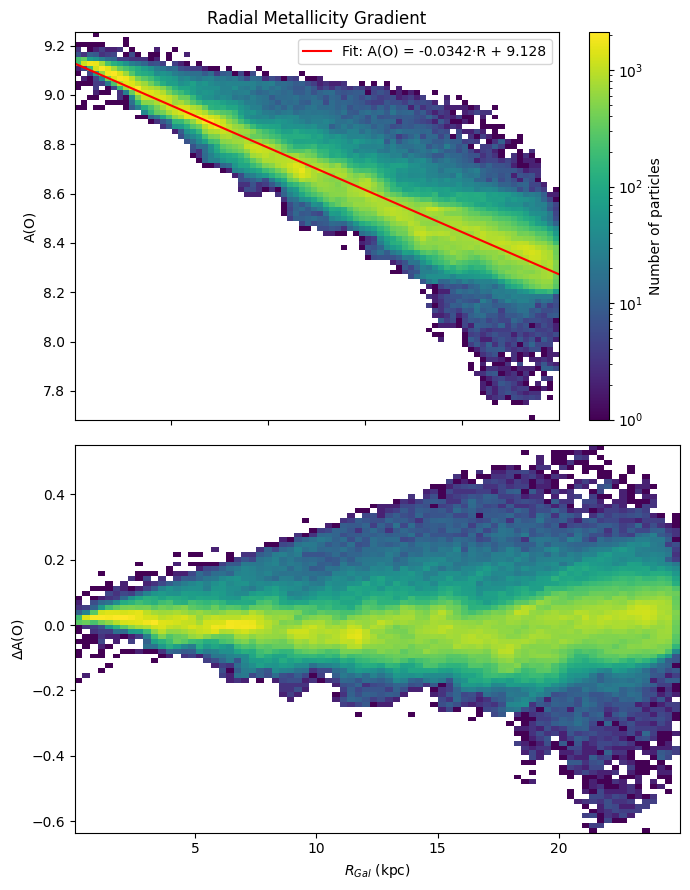

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

#a) log density plot of R_gal vs AO with linear fit and legend
#80 bins (divide plot)
counts, xedges, yedges, image = ax1.hist2d(R_gal, AO, bins=80, cmap='viridis', norm=LogNorm())
fig.colorbar(image, ax=ax1, label='Number of particles')

sort_idx = np.argsort(R_gal)
ax1.plot(R_gal[sort_idx], fit_line[sort_idx], color='red', label=f'Fit: A(O) = {slope:.4f}·R + {intercept:.3f}')

ax1.set_ylabel('A(O)')
ax1.set_title('Radial Metallicity Gradient')
ax1.legend()

#b) residuals of the fit R_gal vs AO
ax2.hist2d(R_gal, residuals, bins=80, cmap='viridis', norm=LogNorm())
ax2.set_xlabel(r'$R_{Gal}$ (kpc)')
ax2.set_ylabel(r'$\Delta$A(O)')

plt.tight_layout()
plt.savefig("figures/3_1_radial_metallicity_gradient.png", dpi=300)
plt.show()

3.2 Fit linear function with intercept and slope

In [17]:
#define linear model function for curve fitting
def linear_model(R, slope, intercept):
    return slope * R + intercept

#choose initial guess to be close to earlier fit result
initial_guess = [-0.03, 9.0]

params, covariance = curve_fit(linear_model, R_gal, AO, p0=initial_guess)
slope_fit, intercept_fit = params

params_errors = np.sqrt(np.diag(covariance))
slope_error, intercept_error = params_errors

print(f"Slope:     {slope_fit:.5f} ± {slope_error:.5f}")
print(f"Intercept: {intercept_fit:.4f} ± {intercept_error:.4f}")
print("Hyperparameters: p0 =", initial_guess)

Slope:     -0.03420 ± 0.00001
Intercept: 9.1278 ± 0.0002
Hyperparameters: p0 = [-0.03, 9.0]


3.3 Linear Fit Discussion

In [18]:
#Overall RMS

rms_overall = np.sqrt(np.mean(residuals**2))
print(f"Overall RMS: {rms_overall:.4f} dex")

# R^2 calculation
ss_res = np.sum(residuals**2) #squared residuals
ss_tot = np.sum((AO - np.mean(AO))**2) #total variance 
r_squared = 1 - (ss_res / ss_tot)

print(f"R² (coefficient of determination): {r_squared:.4f}")

#RMS for binned data
# Define bin edges
bin_edges = np.arange(0, 27.5, 2.5)
bin_labels = []
rms_per_bin = []

for i in range(len(bin_edges) - 1):
    r_low, r_high = bin_edges[i], bin_edges[i+1]
    
    #mask for particles within the current bin
    mask = (R_gal >= r_low) & (R_gal < r_high)
    
    #bin residuals and RMS calculation
    bin_residuals = residuals[mask]
    bin_rms = np.sqrt(np.mean(bin_residuals**2))
    
    bin_labels.append(f"{r_low:.1f}-{r_high:.1f}")
    rms_per_bin.append(bin_rms)

    print(f"R = {r_low:5.1f}-{r_high:5.1f} kpc | N = {mask.sum():6d} | RMS = {bin_rms:.4f} dex")

Overall RMS: 0.0726 dex
R² (coefficient of determination): 0.9125
R =   0.0-  2.5 kpc | N =  23576 | RMS = 0.0295 dex
R =   2.5-  5.0 kpc | N =  42011 | RMS = 0.0337 dex
R =   5.0-  7.5 kpc | N =  49544 | RMS = 0.0395 dex
R =   7.5- 10.0 kpc | N =  44702 | RMS = 0.0564 dex
R =  10.0- 12.5 kpc | N =  50219 | RMS = 0.0641 dex
R =  12.5- 15.0 kpc | N =  50004 | RMS = 0.0762 dex
R =  15.0- 17.5 kpc | N =  55607 | RMS = 0.0835 dex
R =  17.5- 20.0 kpc | N =  66474 | RMS = 0.0915 dex
R =  20.0- 22.5 kpc | N =  63318 | RMS = 0.0905 dex
R =  22.5- 25.0 kpc | N =  66065 | RMS = 0.0827 dex


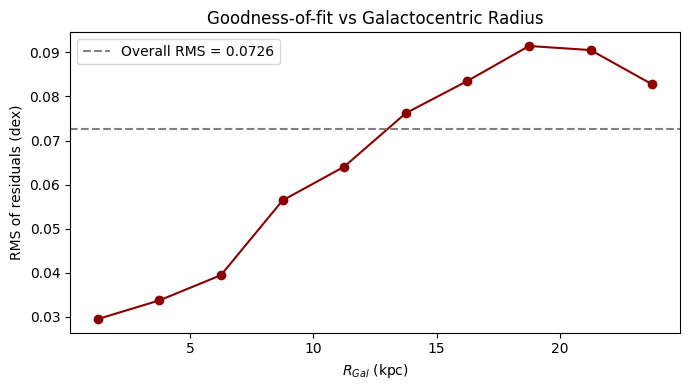

In [19]:
#visualis rms vs radius 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(7, 4))
plt.plot(bin_centers, rms_per_bin, marker='o', color='darkred')
plt.xlabel(r'$R_{Gal}$ (kpc)')
plt.ylabel('RMS of residuals (dex)')
plt.title('Goodness-of-fit vs Galactocentric Radius')
plt.axhline(rms_overall, color='gray', linestyle='--', label=f'Overall RMS = {rms_overall:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig("figures/3_3_rms_vs_radius.png", dpi=300)
plt.show()


The linear model has an overall RMS of 0.0726 dex and R^2 = 0.9125. This means that 91% of the variance in metallicity is captured by the model. Fit quality differs with radius; in the inner disk (R < 5kpc), RMS is low (0.03), eaning the linear gradient is a good local description close to the galactic centre. The fit gets slightly worse through as R increases to 5-17.5kpc. The model performs worst in the R = 17.5-22.5kpc range, with a slight improvement after 22.5kpc. This is indicative of the model, as opposed to noise, as N > 23000 throughout. 

3.4 Three-panel figure for x vs y phlane using the same bins and colourmaps:

In [20]:
#Fitted A(O) using linear model from curve_fit
AO_fit = slope_fit * R_gal + intercept_fit

#residuals of the fit
AO_residuals = AO - AO_fit

n_bins = 60

#a) median of simulated A(O) 
median_sim, xedges, yedges, _ = binned_statistic_2d(x, y, AO, statistic='median', bins=n_bins)

#b) median of fitted A(O)
median_fit, _, _, _ = binned_statistic_2d(x, y, AO_fit, statistic='median', bins=n_bins)

#c) median of residuals
median_residuals, _, _, _ = binned_statistic_2d(x, y, AO_residuals, statistic='median', bins=n_bins)



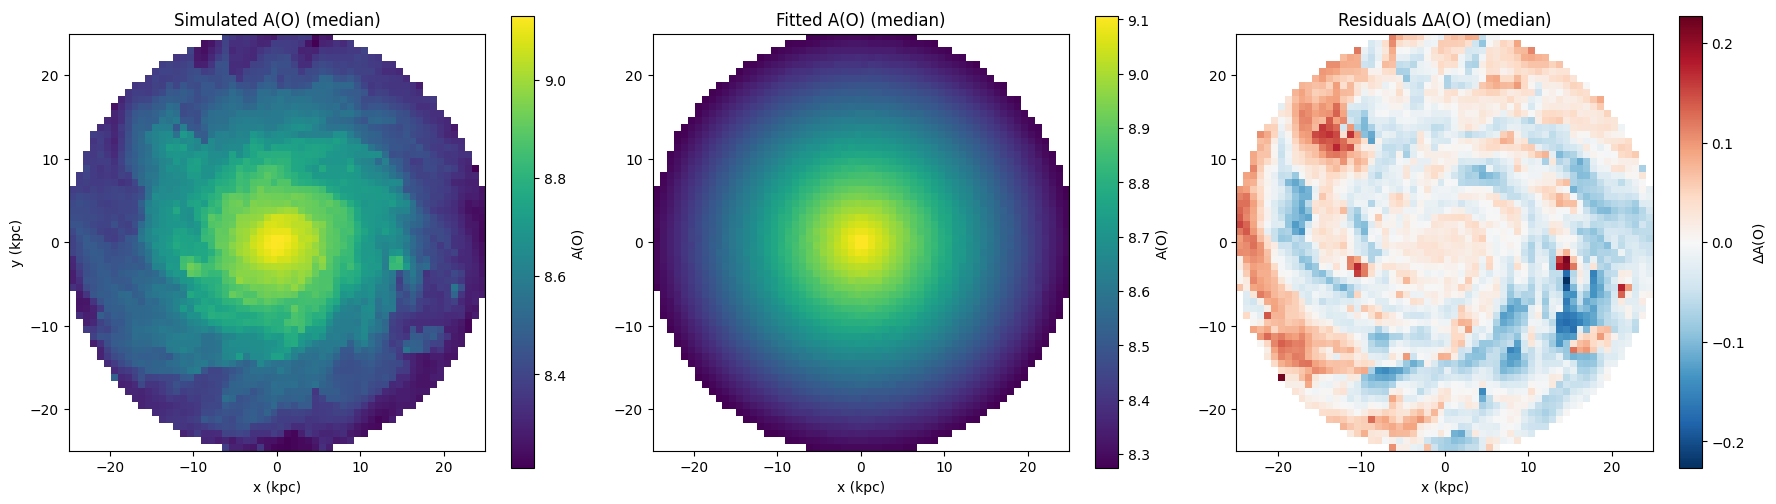

In [21]:
#plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#a) median of simulated A(O)
im0 = axes[0].imshow(median_sim.T, origin='lower', cmap='viridis', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal')
axes[0].set_title('Simulated A(O) (median)')
axes[0].set_xlabel('x (kpc)')
axes[0].set_ylabel('y (kpc)')
fig.colorbar(im0, ax=axes[0], label='A(O)')

#b) median of fitted A(O)
im1 = axes[1].imshow(
    median_fit.T, origin='lower', cmap='viridis', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal')
axes[1].set_title('Fitted A(O) (median)')
axes[1].set_xlabel('x (kpc)')
fig.colorbar(im1, ax=axes[1], label='A(O)')

#c) median of residuals
# colormap centered at 0, since residuals can be positive or negative
residual_limit = np.nanmax(np.abs(median_residuals))  # symmetric color range around 0
im2 = axes[2].imshow(median_residuals.T, origin='lower', cmap='RdBu_r', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal', vmin=-residual_limit, vmax=residual_limit)
axes[2].set_title(r'Residuals $\Delta$A(O) (median)')
axes[2].set_xlabel('x (kpc)')
fig.colorbar(im2, ax=axes[2], label=r'$\Delta$A(O)')

plt.tight_layout()
plt.savefig("figures/3_4_xy_medians.png", dpi=300)
plt.show()

3.5 Binning Choices

n_bins = 60

This means that each bin spans about 0.83kpc across the sky. There are a total of 511520 particles in the disk, so 60x60 bins means that each bin has about 140 particles on average across the disk, which should be enough particles per bin to get a reliable median, but small enough bins to see the structure of the spiral arms.

Fewer (larger) bins would mean that the structure of the arms would be smeared, and one bin is more likely to span both an arm and the interarm gap. 

More (smaller) bins would mean that there are not enough particles per bin, meaning that the medians would be unreliable. Some bins may even be empty, which creates gaps. It would also require more compuational power, and although this data set is small enough that it would not matter, it may be a problem in bigger datasets.

3.6 Analyse residuals in more detail - propose reasonable explanations for patterns